# 16. The `SigmaPole` lineshape

**Objectives:** contrast `SigmaPole`'s LHCb `f0(500)` convention with the plain
`Pole`, evaluate it standalone, embed it in a one-resonance `DecayModel`, and recover
its pole width from a toy fit.

Run cells top to bottom in a fresh kernel. Masses are in GeV, invariants in GeV²,
daughter indices start at zero. Per its docstring, `SigmaPole` uses
`sqrt(s_sigma) = m_sigma - i*Gamma_sigma` and `A(m) = 1 / (s_sigma - m**2)` -- the
width is *not* divided by two, unlike `Pole`.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dalitzplotfitter import (
    DecayChannel, DecayModel, NonResonant, Parameter, Pole, RealImag,
    Resonance, ResonanceContext, SigmaPole, FitSession, generate_toy,
)

## 1. Two conventions, same nominal pole

Both lineshapes read `pole_mass`/`pole_width` from the same `ResonanceContext`, but
combine them differently: `Pole` is `1/(m - m0 - i*Gamma0/2)`, `SigmaPole` is
`1/((m0 - i*Gamma0)**2 - m**2)`. Plotting both against the same nominal mass/width
shows they are numerically distinct shapes, not just different code paths to the
same formula.

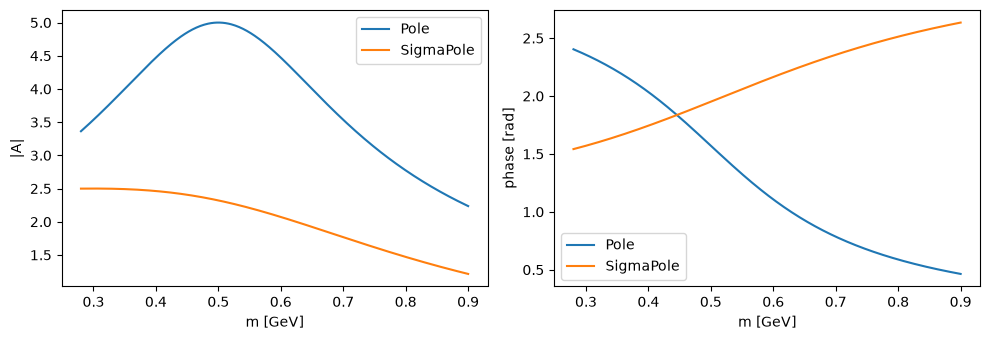

In [2]:
context = ResonanceContext(
    parent_mass=1.869, daughter_masses=(0.13957, 0.13957),
    bachelor_mass=0.13957, spin=0, pole_mass=0.50, pole_width=0.40,
)
mass_scan = jnp.linspace(0.28, 0.9, 400)
pole_amplitude = Pole()(mass_scan, context)
sigma_amplitude = SigmaPole()(mass_scan, context)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(mass_scan, jnp.abs(pole_amplitude), label="Pole")
axes[0].plot(mass_scan, jnp.abs(sigma_amplitude), label="SigmaPole")
axes[0].set(xlabel="m [GeV]", ylabel="|A|")
axes[0].legend()
axes[1].plot(mass_scan, jnp.angle(pole_amplitude), label="Pole")
axes[1].plot(mass_scan, jnp.angle(sigma_amplitude), label="SigmaPole")
axes[1].set(xlabel="m [GeV]", ylabel="phase [rad]")
axes[1].legend()
fig.tight_layout()
plt.show()

## 2. Reproduce the docstring formula directly

Before trusting the class in a fit, reproduce its literal formula with plain
`jax.numpy` and check the two agree exactly.

In [3]:
pole = jnp.asarray(0.50) - 1j * jnp.asarray(0.40)
manual = 1.0 / (pole**2 - mass_scan**2)
np.testing.assert_allclose(sigma_amplitude, manual, atol=1e-12)
print("SigmaPole matches the docstring formula 1/((m0 - i*Gamma0)**2 - m**2).")

SigmaPole matches the docstring formula 1/((m0 - i*Gamma0)**2 - m**2).


## 3. A one-resonance Dalitz model

`SigmaPole` plugs into `Resonance` for the `(0, 1)` pair (`pi- pi+`) of a
`D+ -> pi- pi+ pi+` toy channel, spin 0, just like any other lineshape.

In [4]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
width = Parameter.dynamics("Sigma.width", 0.40, owner="Sigma",
                            bounds=(0.20, 0.70), step=0.005)
model = DecayModel(
    channel,
    components=[
        Resonance("Sigma", (0, 1), RealImag(1.0, 0.0), lineshape=SigmaPole(),
                  mass=0.50, width=width, spin=0),
        NonResonant(RealImag(0.30, -0.15), name="NR"),
    ],
    normalization_method="square-dalitz", normalization_pair=(0, 1),
    normalization_resolution=60,
)
truth = {"Sigma.width": 0.40}
print("Parameters:", [p.name for p in model.parameters])

Parameters: ['Sigma.width']


## 4. Generate a toy and fit the pole width

In [5]:
data = generate_toy(
    model, 1500, parameters=truth, seed=16,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)
print(f"Generated {data.size} events")

session = FitSession(model, data)
result = session.fit({"Sigma.width": 0.34}, simplex=True, ncall=5000)
session.report(result)
assert result.valid, "Inspect the fit diagnostics before trusting this result."


Generated 1500 events


valid=True  NLL=1869.187069
parameter                           value            error
Sigma.width                      0.385328        0.0164767


Fit fractions (physical)
component                    fraction [%]
Sigma                             192.565
NR                                 21.664
sum                               214.228


## 5. Sanity check

In [6]:
fitted_width = float(result.values["Sigma.width"])
error = float(result.errors["Sigma.width"])
print(f"truth={truth['Sigma.width']:.4f}, fit={fitted_width:.4f}, error={error:.4f}")
np.testing.assert_allclose(fitted_width, truth["Sigma.width"], atol=8 * error)
print("SigmaPole width recovered within 8 sigma of its Minuit error.")

truth=0.4000, fit=0.3853, error=0.0165
SigmaPole width recovered within 8 sigma of its Minuit error.


## Continue learning

Compare with the [plain `Pole` convention](tutorial_15_pole.ipynb). See
[lineshapes](../../docs/lineshapes.md).

Return to [the course guide](TUTORIALS.md).